This is (one version of) the classic eight-schools model. An SAT coaching program was run in eight different high schools, resulting in some observed effect $x_i$ in school $i$. It's assumed that this observation is corrupted by (known) Gaussian noise. It's assumed that all effects are drawn from some unknown Gaussian distribution. The goal is to estimate that shared distribution as well as the true effect $z_i$ for each school.

Formally, the model is

$$
\begin{align}

\mu & \sim \mathrm{normal}(0, 10) \\
\tau & \sim \mathrm{lognormal}(0, 5) \\
z_i & \sim \mathrm{normal}(\mu, \tau) \\
x_i & \sim \mathrm{normal}(z_i, \sigma_i).

\end{align}
$$

Then, after observing the vector $x$ and the standard deviations $\sigma$, the goal is to estimate the vector $z$.

In [56]:
# setup
import numpy as np

N = 8
stddevs = np.array([15, 10, 16, 11, 9, 11, 10, 18])
x_obs = np.array([28, 8, -3, 7, -1, 1, 18, 12])

In [41]:
# pangolin

import pangolin
from pangolin import interface as pi

mu = pi.normal(0,10)
tau = pi.lognormal(0,5)
z = pi.vmap(pi.normal, None, N)(mu, tau)
x = pi.vmap(pi.normal)(z, stddevs)

z_samps = pangolin.blackjax.sample(z, x, x_obs, niter=10000)
print(np.mean(z_samps, axis=0))

[7.7884827 6.938321  6.427393  6.8576765 6.092994  6.4019165 7.7459593
 6.985982 ]


Text(35.472222222222214, 0.5, 'treatment effect')

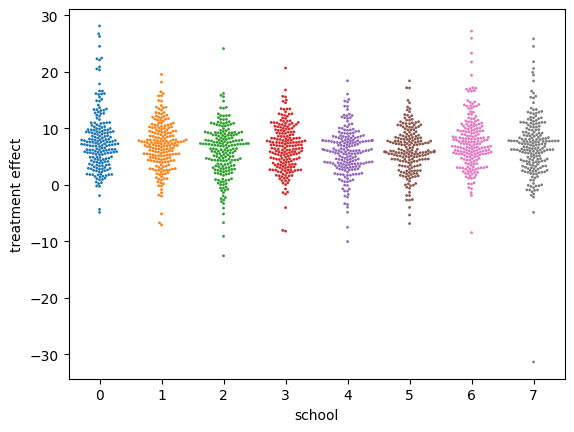

In [ ]:
# plot samples

import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
sns.swarmplot(z_samps[::50,:],s=2,zorder=0)
plt.xlabel('school')
plt.ylabel('treatment effect')

In [ ]:
# pymc

import pymc as pm

with pm.Model():
    mu = pm.Normal('mu', 0, 10)
    tau = pm.LogNormal('tau', 0, 5)
    z = pm.Normal('z', mu, tau, size=N)
    x = pm.Normal('x', z, stddevs, observed=x_obs)

    trace = pm.sample(draws=10000, chains=1)
    z_samps = trace.posterior['z'].values[0,:,:]

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [mu, tau, z]


Output()

Sampling 1 chain for 1_000 tune and 10_000 draw iterations (1_000 + 10_000 draws total) took 5 seconds.
There were 990 divergences after tuning. Increase `target_accept` or reparameterize.
Only one chain was sampled, this makes it impossible to run some convergence checks


[8.03352928 7.01272384 6.3454182  6.92713654 6.03970133 6.32703657
 8.02932177 7.02524634]


In [60]:
# pyro

import pyro
import torch

stddevs_torch = torch.tensor(stddevs)
x_obs_torch = torch.tensor(x_obs)

def model():
    mu = pyro.sample('mu', pyro.distributions.Normal(0, 10))
    tau = pyro.sample('tau', pyro.distributions.LogNormal(0, 5))
    with pyro.plate('N', N):
        z = pyro.sample('z', pyro.distributions.Normal(mu, tau))
        x = pyro.sample('x', pyro.distributions.Normal(z, stddevs_torch), obs=x_obs_torch)

nuts_kernel = pyro.infer.mcmc.NUTS(model)
mcmc = pyro.infer.mcmc.MCMC(nuts_kernel, warmup_steps=500, num_samples=1000, num_chains=1)
mcmc.run()
z_samps = mcmc.get_samples()['z'].numpy()
print(np.mean(z_samps, axis=0))

Sample: 100%|██████████| 1500/1500 [01:14, 20.26it/s, step size=2.14e-01, acc. prob=0.547] 

[ 10.924454    6.748828  -25.055782  -19.33764     9.516961  -37.730747
  18.677956   -5.7512417]


In [84]:
# numpyro

import numpyro
import jax

stddevs_torch = torch.tensor(stddevs)
x_obs_torch = torch.tensor(x_obs)

def model():
    mu = numpyro.sample('mu', numpyro.distributions.Normal(0, 10))
    tau = numpyro.sample('tau', numpyro.distributions.LogNormal(0, 5))
    with numpyro.plate('N',N):
        z = numpyro.sample('z', numpyro.distributions.Normal(mu, tau))
        x = numpyro.sample('x', numpyro.distributions.Normal(z, stddevs), obs=x_obs)

nuts_kernel = numpyro.infer.NUTS(model)
mcmc = numpyro.infer.MCMC(nuts_kernel, num_warmup=500, num_samples=1000, num_chains=1)
mcmc.run(jax.random.PRNGKey(42))
z_samps = mcmc.get_samples()['z']
np.mean(z_samps, axis=0)

sample: 100%|██████████| 1500/1500 [00:02<00:00, 716.81it/s, 3 steps of size 1.50e-01. acc. prob=0.71] 


Array([7.984607 , 6.26257  , 5.2180676, 6.162221 , 5.4168835, 5.536943 ,
       7.863696 , 6.311456 ], dtype=float32)

In [ ]:
# pyjags

# very slow to mix, need a LOT of iterations

import pyjags

model_code = """
model {
  mu ~ dnorm(0, 1/10^2)
  tau ~ dlnorm(0, 1/5^2)
  for (i in 1:N) {
    z[i] ~ dnorm(mu, 1/tau^2)
    x[i] ~ dnorm(z[i], 1/stddevs[i]^2)
  }
}
"""

model = pyjags.Model(
    code=model_code,
    data={'N': N, 'stddevs': stddevs.tolist(), 'x': x_obs.tolist()},
    chains=1,
    adapt=5000
)

samples = model.sample(100000, ['z'])
z_samps = np.array(samples['z'])[:,:,0].T
print(np.mean(z_samps, axis=0))

adapting: iterations 5000 of 5000, elapsed 0:00:00, remaining 0:00:00


sampling: iterations 100000 of 100000, elapsed 0:00:00, remaining 0:00:00
[7.24292188 7.16207055 7.11858631 7.15562228 7.06439821 7.11312203
 7.24971219 7.16625207]


In [91]:
# stan

import cmdstanpy
import tempfile
from pathlib import Path

stan_code = """
data {
  int<lower=0> N;
  array[N] real x;
  array[N] real stddevs;
}
parameters {
  real mu;
  real<lower=0> tau;
  array[N] real z;
}
model {
  mu ~ normal(0, 10);
  tau ~ lognormal(0, 5);
  for (i in 1:N) {
    z[i] ~ normal(mu, tau);
    x[i] ~ normal(z[i], stddevs[i]);
  }
}
"""

with tempfile.TemporaryDirectory() as tmpdir:
    stan_file = Path(tmpdir) / "8schools_model.stan"
    stan_file.write_text(stan_code)

    model = cmdstanpy.CmdStanModel(stan_file=str(stan_file))

    fit = model.sample(
        data={'N': N, 'stddevs': stddevs, 'x': x_obs},
        chains=1,
        iter_warmup=500,
        iter_sampling=1000,
        seed=42
    )
    z_samps = fit.stan_variable('z')
print(np.mean(z_samps, axis=0))

16:08:21 - cmdstanpy - INFO - compiling stan file /tmp/tmphexhbzxy/8schools_model.stan to exe file /tmp/tmphexhbzxy/8schools_model
16:08:29 - cmdstanpy - INFO - compiled model executable: /tmp/tmphexhbzxy/8schools_model
16:08:29 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

16:08:29 - cmdstanpy - INFO - CmdStan done processing.
16:08:29 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 56 divergent transitions (5.6%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.



[7.64341913 6.49855166 5.83051106 6.53148887 5.82838491 6.04616346
 7.64902169 6.49342296]
